<p class="mlx-kicker">Part II &middot; Architecture &middot; Chapter 6</p>

# 6. Normalization: from BatchNorm to QK-norm

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 25 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, chapter 5, mean and variance</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/transformer-explained/blob/main/chapters/06-normalization/index.ipynb)

![The three generations of normalization. Each column highlights the one part that is new: statistics computed over the batch, statistics computed over one token and placed inside the residual branch, and a cheaper norm without the mean that is also applied to queries and keys.](figures/norm-lineage.svg)

## What changed, and why it works

A normalization layer rescales the numbers flowing through a network so that they have a fixed size, then lets the network learn the size it actually wants through a gain and a bias. Every modern Transformer has two or more per block. The surprise of this chapter is that the original reason given for normalization, reducing "internal covariate shift", turned out not to be why it works. The real benefit is about the scale of activations, gradients and attention logits, and each generation in Figure 6.1 controls a different scale.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; BatchNorm</p><h3>Normalize each feature over the batch</h3><p><b>What changed.</b> After a linear layer, each feature is shifted and scaled to mean 0 and variance 1, using the statistics of the current mini-batch. A learned gain and bias follow.</p><p><b>Why it works.</b> Not mainly by keeping layer inputs stable. Normalizing makes the loss insensitive to the scale of the weights, so a large step cannot blow up the activations, and the gradient changes more slowly from one point to the next. A smoother surface tolerates a much larger learning rate. <b>[likely]</b></p><p class="mlx-why__run">Our runs: without normalization an 8-layer MLP diverges above lr 0.1; with BatchNorm it still trains at lr 1.0</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; LayerNorm, pre-norm</p><h3>Normalize each token, inside the residual branch</h3><p><b>What changed.</b> LayerNorm computes the statistics over one token's own features, so it does not depend on the batch. Pre-norm then moves it from after the residual addition to the start of each branch: <code>x + f(norm(x))</code>.</p><p><b>Why it works.</b> Batch statistics are unreliable for sequences of different lengths, small batches and one-token-at-a-time generation; per-token statistics work identically in training and inference. In pre-norm, the residual stream is never normalized, so there is a plain identity path from the loss to every layer and the gradient does not depend on depth.</p><p class="mlx-why__run">Our runs, 12 layers at lr 0.01: post-norm stalls at 3.39, pre-norm reaches 2.20</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; RMSNorm, QK-norm</p><h3>Drop the mean, then normalize queries and keys</h3><p><b>What changed.</b> RMSNorm divides by the root mean square and skips the mean subtraction and the bias. QK-norm adds one more RMSNorm (or LayerNorm) to the queries and keys of each head, just before their dot product.</p><p><b>Why it works.</b> The rescaling is what matters; the re-centring adds cost and little else. An attention logit is a product of two learned projections, so it grows roughly with the square of the weights. Normalizing q and k bounds every logit, so the softmax cannot collapse onto one token when training pushes the weights up.</p><p class="mlx-why__run">Our runs: RMSNorm 2.20, LayerNorm 2.20; largest attention logit 1532 without QK-norm, 21 with</p></section>
</div>

Read left to right, the pressure moves from *making deep networks train at all*, to *removing the dependence on the batch*, to *keeping very deep, very large Transformers stable at high learning rates*. Each step below rebuilds one change and tests it.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| before 2015 | No normalization | minor | careful initialization and small learning rates; inputs standardized once |
| 2015 | BatchNorm | **major** | normalize each feature over the mini-batch; much faster training of deep CNNs |
| 2016 | LayerNorm | **major** | normalize each example over its own features; no batch dependence |
| 2017 | Post-norm Transformer | minor | LayerNorm after every residual addition; needs learning-rate warmup |
| 2018 | Covariate shift questioned | minor | Santurkar et al. show BatchNorm works for a different reason |
| 2019-2020 | Pre-norm | **major** | LayerNorm moves inside the residual branch (GPT-2, Xiong et al.) |
| 2019 | RMSNorm | minor | drop the mean and the bias; T5, LLaMA and most current LLMs |
| 2020, then 2023 | QK-norm | minor | normalize queries and keys; adopted at scale after ViT-22B |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| nothing to BatchNorm | deep networks needed small learning rates and careful initialization | learning rates several times larger, less sensitivity to initialization |
| BatchNorm to LayerNorm | batch statistics break down for sequences, small batches and generation | normalization that treats each example alone, the same in training and inference |
| post-norm to pre-norm | deep Transformers diverged unless warmup was tuned carefully | an identity path through the whole network; stable training at depth |
| LayerNorm to RMSNorm | the mean subtraction costs time and does not seem to help | a simpler, slightly cheaper norm at the same quality |
| adding QK-norm | attention logits that grow until the softmax collapses | a bound on every logit, so high learning rates stay stable |

The story the field told about normalization changed more than the layers did. BatchNorm was introduced to fix "internal covariate shift", the drift of each layer's input distribution as earlier layers learn. Three years later, experiments showed that BatchNorm still works when that drift is deliberately made worse, and the explanation moved to the geometry of the loss surface. The later generations were designed with that view in mind: each one keeps some scale in check (of the residual branch, of the gradient through depth, of the attention logits) rather than trying to keep distributions fixed.

**Still open:** which of the competing explanations of BatchNorm (smoothness, automatic learning-rate tuning through scale invariance, or regularization by batch noise) carries most of the weight; why post-norm models, when they do train, sometimes end up slightly better than pre-norm ones; and whether normalization is needed at all, since careful initialization and scaled residuals can train some deep networks without it.

## Diverged branches

The evolution path follows the line today's models inherited. At a few points the field split instead: two camps made different bets on the same problem, and sometimes both bets are still alive. Each tab below is one such fork, with the two branches, why they split, and how it has played out so far.

<div class="mlx-why mlx-forks" data-label="Forks in this lineage">
<section class="mlx-why__card mlx-why__card--1 mlx-fork"><p class="mlx-why__n">Fork 1 &middot; 2016-2022</p><h3>BatchNorm for images, LayerNorm for text?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">BatchNorm <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Normalize each channel over the mini-batch. Ideal for large batches of same-sized images.</p><p class="mlx-fork__who">ResNet, EfficientNet, most CNNs</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">LayerNorm and RMSNorm <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Normalize each example over its own features, with no dependence on the batch.</p><p class="mlx-fork__who">every Transformer, ViT, ConvNeXt</p></div></div><p><b>Why they split.</b> Batch statistics break down with small batches, variable-length sequences, and when generating one token at a time. Images had none of those problems, text had all of them.</p><p><b>How it played out.</b> As vision moved to Transformers, LayerNorm went with it, and BatchNorm survives where CNNs do. ConvNeXt showed the swap costs nothing even inside a convolutional network. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--2 mlx-fork"><p class="mlx-why__n">Fork 2 &middot; 2021-2025</p><h3>Keep normalization, or remove it?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Normalized <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>A norm in every block, now usually RMSNorm.</p><p class="mlx-fork__who">almost every model</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Normalizer-free <span class="mlx-fork__state mlx-fork__state--rival">contender</span></p><p>Control activation scale another way. NFNets train ResNets without BatchNorm using scaled residual branches and adaptive gradient clipping; Dynamic Tanh replaces every LayerNorm in a Transformer with an element-wise tanh(&alpha;x).</p><p class="mlx-fork__who">NFNets, Dynamic Tanh</p></div></div><p><b>Why they split.</b> Norms cost memory traffic (and, for BatchNorm, synchronization across devices), and why they help is only partly understood. If their job is to control scale, a cheaper mechanism might do.</p><p><b>How it played out.</b> NFNets matched BatchNorm ResNets on ImageNet but did not catch on, as vision moved to Transformers. Dynamic Tanh is recent and reports parity across several model types, but has not yet been shown in a large production LLM. <strong>[speculative]</strong></p></section>
<section class="mlx-why__card mlx-why__card--3 mlx-fork"><p class="mlx-why__n">Fork 3 &middot; 2024-2025</p><h3>Pre-norm only, or a norm on the way out too?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Pre-norm <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p><code>x + f(norm(x))</code>: normalize the block's input, add its raw output to the stream.</p><p class="mlx-fork__who">LLaMA and most open LLMs</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Output norm <span class="mlx-fork__state mlx-fork__state--rival">contender</span></p><p>Also normalize what the block writes. Gemma 2 normalizes both the input and the output of each sub-layer; OLMo 2 normalizes only the output, <code>x + norm(f(x))</code>.</p><p class="mlx-fork__who">Gemma 2, OLMo 2</p></div></div><p><b>Why they split.</b> Pre-norm lets a block write arbitrarily large values into the stream, and the stream's scale grows with depth. Normalizing the output bounds each block's contribution; OLMo 2 reports more stable training.</p><p><b>How it played out.</b> Too new to call. Both forms keep the identity path clean, which chapter 7 shows matters most; they differ only in how much each block may write. <strong>[speculative]</strong></p></section>
</div>

## Run it yourself

The steps share this setup. Step 1 uses a small MLP on synthetic data; the later steps use TinyShakespeare and a Transformer whose normalization we can configure. Every experiment runs on a laptop CPU in about two minutes or less.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/transformer-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import copy, math, time
from mlexp.transformer import RMSNorm, SwiGLU, apply_rope

torch.set_num_threads(1)  # the timings quoted in the text used one thread; raise this on your machine
tok, train_ids, val_ids = mlexp.load_char_corpus()

### Step 1 (major): BatchNorm

#### The problem before

A deep network is a long chain of multiplications. If each layer slightly enlarges its input, the activations grow exponentially with depth; if each layer slightly shrinks it, they vanish (chapter 5 showed the gradient version of this). Before 2015 the cure was careful initialization and a small learning rate, because one large update could push the weights into the regime where everything explodes.

#### The idea

Ioffe and Szegedy (2015) proposed to standardize every feature after every linear layer: subtract its mean, divide by its standard deviation, so that each layer always sees inputs of the same size. Computing exact statistics over the whole dataset after every update is too expensive, so they used the statistics of the current **mini-batch**. A learned gain `\(\gamma\)` and bias `\(\beta\)` follow, so the layer can still represent any mean and scale it needs. At inference time, when there may be no batch, running averages of the mean and variance collected during training are used instead.

Their motivation was **internal covariate shift**: as earlier layers learn, the distribution of each layer's input keeps moving, and the layer has to keep re-adapting. BatchNorm let an Inception network reach the same accuracy in 14 times fewer steps, with a much larger learning rate. Whether covariate shift was the reason is the question of this step.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: batch normalization of feature j</p><div class="mlx-eq">$$\hat{x}_{ij} = \frac{x_{ij} - \mu_j}{\sqrt{\sigma_j^2 + \epsilon}}, \qquad y_{ij} = \gamma_j\, \hat{x}_{ij} + \beta_j, \qquad \mu_j = \frac{1}{B}\sum_{i=1}^{B} x_{ij}, \quad \sigma_j^2 = \frac{1}{B}\sum_{i=1}^{B} (x_{ij} - \mu_j)^2$$</div><p class="mlx-eq__where">\(i\) runs over the \(B\) examples in the batch and \(j\) over features. The statistics are taken down a column of the batch, so every output depends on the other examples.</p></div>

#### Minimal implementation

In [3]:
class BatchNorm(nn.Module):
    """Normalize each feature using the mean and variance of the current batch."""

    def __init__(self, dim, momentum=0.1, eps=1e-5):
        super().__init__()
        self.momentum, self.eps = momentum, eps
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))
        self.register_buffer("running_mean", torch.zeros(dim))  # used at inference time
        self.register_buffer("running_var", torch.ones(dim))

    def forward(self, x):  # x: (batch, features)
        if self.training:
            mean, var = x.mean(0), x.var(0, unbiased=False)
            with torch.no_grad():
                self.running_mean.lerp_(mean, self.momentum)
                self.running_var.lerp_(x.var(0), self.momentum)
        else:
            mean, var = self.running_mean, self.running_var
        return self.gamma * (x - mean) / torch.sqrt(var + self.eps) + self.beta


x = 3 * torch.randn(64, 16) + 5
ours, ref = BatchNorm(16), nn.BatchNorm1d(16)
print("training mode matches nn.BatchNorm1d: ", torch.allclose(ours(x), ref(x), atol=1e-5))
ours.eval(), ref.eval()
print("inference mode matches nn.BatchNorm1d:", torch.allclose(ours(x), ref(x), atol=1e-5))

training mode matches nn.BatchNorm1d:  True
inference mode matches nn.BatchNorm1d: True


#### Experiment: how large a learning rate can each network take?

Our test bed is an 8-layer ReLU MLP that classifies points from 8 overlapping Gaussian clusters in 32 dimensions. Both versions use He initialization (chapter 11), so the plain network starts in good shape too; the only difference is a BatchNorm after every hidden linear layer. We train each with SGD and momentum for 400 steps, at learning rates from 0.001 to 3, and report validation accuracy. About 20 seconds in total.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Both MLPs are trained at eight learning rates, from 0.001 to 3. Which one reaches the higher best accuracy, and which one survives the larger learning rate?</p><details><summary>Show what happened</summary><p>The best accuracies are nearly the same (0.824 without normalization, 0.827 with BatchNorm). The difference is the range: the plain network diverges at lr 0.3 and above, while the BatchNorm network still trains at lr 1.0, ten times higher than the plain network's limit. At the smallest learning rate BatchNorm is actually behind (0.656 against 0.752).</p></details></div>

learning rate       0.001   0.003    0.01    0.03     0.1     0.3       1       3
no normalization    0.752   0.793   0.804   0.817   0.824   (div)   (div)   (div)
BatchNorm           0.656   0.763   0.788   0.798   0.815   0.827   0.825   0.125


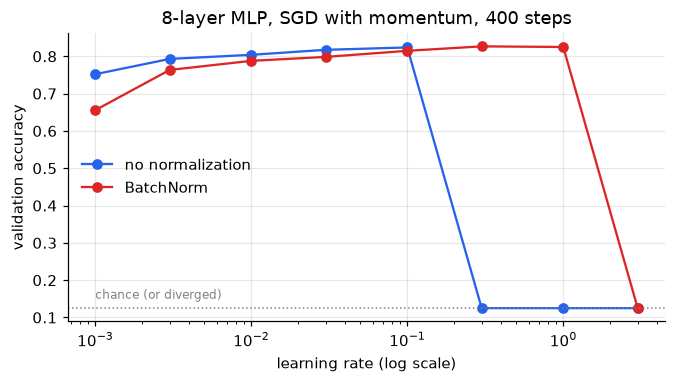

In [4]:
# Synthetic data: 8 heavily overlapping Gaussian clusters in 32 dimensions.
g = torch.Generator().manual_seed(0)
centers = torch.randn(8, 32, generator=g)


def make_data(n):
    y = torch.randint(8, (n,), generator=g)
    return centers[y] + 2.0 * torch.randn(n, 32, generator=g), y


X, Y = make_data(8192)
X_val, Y_val = make_data(4096)


def make_mlp(norm=None, depth=8, width=128):
    """An 8-layer ReLU MLP; norm(width) is inserted after every hidden Linear."""
    layers, d = [], 32
    for _ in range(depth):
        layers += [nn.Linear(d, width)] + ([norm(width)] if norm else []) + [nn.ReLU()]
        d = width
    layers.append(nn.Linear(d, 8))
    for m in layers:
        if isinstance(m, nn.Linear):  # He initialization: the right scale for ReLU
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)
    return nn.Sequential(*layers)


def train_mlp(model, lr, steps=400, batch=128, seed=0):
    """SGD with momentum. Returns validation accuracy, or nan if the loss blew up."""
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    for _ in range(steps):
        idx = torch.randint(len(X), (batch,), generator=gen)
        loss = F.cross_entropy(model(X[idx]), Y[idx])
        if not torch.isfinite(loss):
            return float("nan")
        opt.zero_grad()
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        return (model(X_val).argmax(1) == Y_val).float().mean().item()


lrs = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
acc = {"no normalization": [], "BatchNorm": []}
for lr in lrs:
    for name, norm in [("no normalization", None), ("BatchNorm", BatchNorm)]:
        torch.manual_seed(0)
        acc[name].append(train_mlp(make_mlp(norm), lr))

print("learning rate    " + "".join(f"{lr:>8g}" for lr in lrs))
for name, a in acc.items():
    print(f"{name:17s}" + "".join("   (div)" if math.isnan(v) else f"{v:8.3f}" for v in a))

fig, ax = plt.subplots(figsize=(7, 3.4))
for name, a in acc.items():
    a = np.array(a)
    ax.semilogx(lrs, np.where(np.isnan(a), 0.125, a), marker="o", label=name)
ax.axhline(0.125, color="gray", ls=":", lw=1)
ax.text(lrs[0], 0.15, "chance (or diverged)", fontsize=8, color="gray")
ax.set(xlabel="learning rate (log scale)", ylabel="validation accuracy",
       title="8-layer MLP, SGD with momentum, 400 steps")
ax.legend(frameon=False);

#### Experiment: is it really about covariate shift?

Santurkar et al. (2018) tested the covariate-shift story directly. If BatchNorm works by keeping each layer's input distribution fixed, then *adding* shift right after it should destroy the benefit. We repeat their idea: after every BatchNorm, we multiply each feature by a random factor between 1 and 1.4 and add a random offset with standard deviation 0.4, freshly drawn at every training step. The next layer now sees an input distribution that jumps around far more than in the plain network.

In [5]:
class NoisyBatchNorm(BatchNorm):
    """BatchNorm followed by a random rescale and shift that change at every training step."""

    def __init__(self, dim, noise=0.2):
        super().__init__(dim)
        self.noise = noise

    def forward(self, x):
        x = super().forward(x)
        if self.training:
            scale = 1 + 2 * self.noise * torch.rand(x.shape[1])
            shift = 2 * self.noise * torch.randn(x.shape[1])
            x = x * scale + shift
        return x


for lr in [0.1, 0.3]:
    torch.manual_seed(0)
    noisy = train_mlp(make_mlp(NoisyBatchNorm), lr)
    clean = acc["BatchNorm"][lrs.index(lr)]
    plain = acc["no normalization"][lrs.index(lr)]
    print(f"lr {lr}:  no normalization {plain:.3f}   BatchNorm {clean:.3f}   BatchNorm + injected shift {noisy:.3f}")

lr 0.1:  no normalization 0.824   BatchNorm 0.815   BatchNorm + injected shift 0.797


lr 0.3:  no normalization nan   BatchNorm 0.827   BatchNorm + injected shift 0.722


The injected shift costs accuracy: 2 points at lr 0.1 (0.797 against 0.815) and 10 points at lr 0.3 (0.722 against 0.827). Our shift is large, and the noise itself makes optimization harder. But the network still trains at lr 0.3, where the plain network diverges. Whatever BatchNorm does for the learning rate, most of it survives a deliberate increase in covariate shift.

#### Experiment: how smooth is the loss surface?

Santurkar et al. proposed a different mechanism: BatchNorm makes the loss surface smoother. One way to measure smoothness is to take the current gradient `\(g\)`, step a distance `\(\eta\)` along it, and see how much the gradient changes. The ratio `\(\lVert \nabla L(w - \eta g) - \nabla L(w) \rVert / \lVert \eta g \rVert\)` is a local estimate of `\(\beta\)`, the "gradient Lipschitz constant". Gradient descent with step size `\(\eta\)` is stable roughly when `\(\eta < 2/\beta\)`, so a smaller `\(\beta\)` directly means a larger usable learning rate. We probe four step sizes every 5 training steps, at lr 0.1 where both networks train.

no normalization  beta after step 50: median  11.1, max  38.3   largest loss spread 9.62
BatchNorm         beta after step 50: median   4.5, max   6.0   largest loss spread 0.94


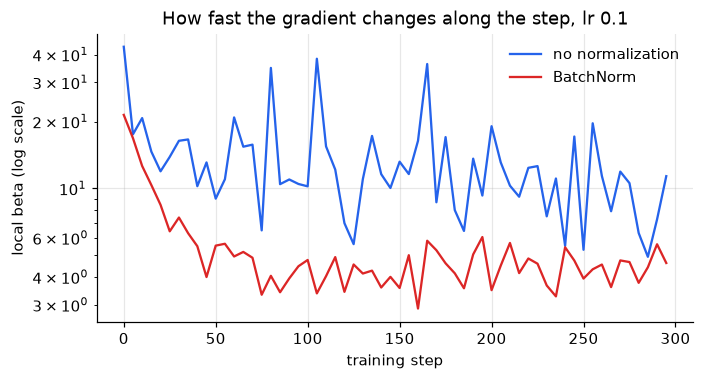

In [6]:
def smoothness_trace(norm, lr=0.1, steps=300, every=5, etas=(0.025, 0.05, 0.1, 0.2)):
    """Train, and every few steps probe the loss surface along the gradient direction.

    beta = largest ||grad(w - eta g) - grad(w)|| / ||eta g|| over the probe steps (smaller = smoother).
    spread = how much the loss itself varies over those probe steps."""
    torch.manual_seed(0)
    model = make_mlp(norm)
    gen = torch.Generator().manual_seed(0)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    trace = {"step": [], "beta": [], "spread": []}
    for step in range(steps):
        idx = torch.randint(len(X), (128,), generator=gen)
        xb, yb = X[idx], Y[idx]
        loss = F.cross_entropy(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        if step % every == 0:
            g = [p.grad.clone() for p in model.parameters()]
            g_norm = torch.sqrt(sum((gi**2).sum() for gi in g))
            betas, losses = [], []
            for eta in etas:
                probe = copy.deepcopy(model)
                with torch.no_grad():
                    for p, gi in zip(probe.parameters(), g):
                        p -= eta * gi
                probe_loss = F.cross_entropy(probe(xb), yb)
                probe_grad = torch.autograd.grad(probe_loss, list(probe.parameters()))
                diff = torch.sqrt(sum(((a - b) ** 2).sum() for a, b in zip(probe_grad, g)))
                betas.append((diff / (eta * g_norm)).item())
                losses.append(probe_loss.item())
            trace["step"].append(step)
            trace["beta"].append(max(betas))
            trace["spread"].append(max(losses) - min(losses))
        opt.step()
    return trace


traces = {"no normalization": smoothness_trace(None), "BatchNorm": smoothness_trace(BatchNorm)}
fig, ax = plt.subplots(figsize=(7, 3.4))
for name, t in traces.items():
    ax.semilogy(t["step"], t["beta"], label=name)
    later = [b for s, b in zip(t["step"], t["beta"]) if s >= 50]
    print(f"{name:17s} beta after step 50: median {np.median(later):5.1f}, max {max(later):5.1f}"
          f"   largest loss spread {max(t['spread']):.2f}")
ax.set(xlabel="training step", ylabel="local beta (log scale)", title="How fast the gradient changes along the step, lr 0.1")
ax.legend(frameon=False);

#### Why it worked: a post-mortem

**BatchNorm widens the range of usable learning rates.** In our sweep it did not raise the best accuracy, but it let training run at a learning rate ten times higher. This matches the original paper and the careful study of Bjorck et al. (2018), who traced most of BatchNorm's benefit to the larger learning rate it allows. **[established]**

**Covariate shift is not the main reason.** With extra shift injected after every BatchNorm, the network still trained at a learning rate where the plain network diverged, although it lost some accuracy. Santurkar et al. (2018) found the same on image classifiers, with an even smaller loss, and also showed that BatchNorm does not necessarily reduce covariate shift by their measures. **[established]** that it works despite shift; the claim that shift is irrelevant is stronger than the evidence.

**The loss surface is smoother.** After step 50, the local `\(\beta\)` of the BatchNorm network has a median of 4.5 and never exceeds 6.0, while the plain network's median is 11.1 with spikes to 38.3. Along the same probe steps, the plain network's loss varied by up to 9.62 nats, the BatchNorm network's by at most 0.94. With `\(\eta < 2/\beta\)` as a rough guide, that is the difference between a learning rate that is safe and one that is not. This is the mechanism Santurkar et al. proposed. Note that both networks start rough at initialization; BatchNorm's advantage appears along the training trajectory. **[likely]**

**Other explanations still compete.** Because BatchNorm makes the output independent of the scale of the weights in front of it, the weights tend to grow during training, which quietly lowers the effective learning rate (Arora et al., 2018). **[likely]** The noise from batch statistics also acts as a regularizer. **[likely]** These mechanisms are not exclusive, and which one dominates depends on the setting.

**The price: every output depends on the batch.** Statistics from 128 examples are noisy with small batches, undefined for a single example, and different between training and inference. For language models, where sequences vary in length and generation runs one token at a time, this was a serious problem, and it set up the next step.

### Step 2 (minor): LayerNorm

Ba, Kiros and Hinton (2016) kept the normalization but turned it sideways: the mean and variance are computed over the features of **one example** (one token, in a Transformer), not over the batch. Nothing depends on the other examples, so training and inference compute exactly the same function and no running averages are needed. They designed it for recurrent networks, where batch statistics would have to be kept separately for every time step. The Transformer adopted it from the start.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: layer normalization of one token x</p><div class="mlx-eq">$$\mathrm{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta, \qquad \mu = \frac{1}{d}\sum_{j=1}^{d} x_j, \quad \sigma^2 = \frac{1}{d}\sum_{j=1}^{d} (x_j - \mu)^2$$</div><p class="mlx-eq__where">Same formula as BatchNorm, but the sums run over the \(d\) features of one token instead of over the examples in a batch.</p></div>

In [7]:
class LayerNorm(nn.Module):
    """Normalize each token vector over its own features, then apply a learned gain and bias."""

    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
        self.bias = nn.Parameter(torch.zeros(dim))

    def forward(self, x):  # x: (..., features)
        mean = x.mean(-1, keepdim=True)
        var = (x - mean).pow(2).mean(-1, keepdim=True)
        return self.weight * (x - mean) * torch.rsqrt(var + self.eps) + self.bias


torch.manual_seed(0)
x = torch.randn(8, 16)
other_batch = torch.cat([x[:1], 3 * torch.randn(7, 16) + 2])  # same first example, different batch-mates
for name, norm in [("BatchNorm", BatchNorm(16)), ("LayerNorm", LayerNorm(16))]:
    change = (norm(x)[0] - norm(other_batch)[0]).abs().max().item()
    print(f"{name}: output for example 0 changes by up to {change:.3f} when its batch-mates change")
print("LayerNorm matches nn.LayerNorm:", torch.allclose(LayerNorm(16)(x), nn.LayerNorm(16)(x), atol=1e-5))

BatchNorm: output for example 0 changes by up to 2.032 when its batch-mates change
LayerNorm: output for example 0 changes by up to 0.000 when its batch-mates change
LayerNorm matches nn.LayerNorm: True


The same example gets a different BatchNorm output depending on which other examples share its batch; its LayerNorm output does not change at all. That property is why every language model since 2017 normalizes per token. **[established]**

### Step 3 (major): where the norm goes, post-norm vs pre-norm

#### The problem before

The original Transformer (Vaswani et al., 2017) put LayerNorm *after* each residual addition: `x = norm(x + f(x))`. This is **post-norm**. It worked for 6-layer models, but only with a learning-rate warmup, and deeper post-norm models often diverged early in training. Practitioners found that the fix was to move the norm to the *start* of each branch: `x = x + f(norm(x))`, **pre-norm**. GPT-2 (Radford et al., 2019) used it, Wang et al. (2019) trained 30-layer translation models with it, and Xiong et al. (2020) explained why it removes the need for warmup.

#### The idea

In post-norm, every path from the loss back to an early layer passes through a LayerNorm per sub-layer, 24 of them in a 12-block model. Each one rescales the gradient depending on the current activations, and Xiong et al. showed that at initialization the gradients of the last layers are large, so an early update with a full learning rate is destructive. Warmup hides this by keeping the first updates small.

In pre-norm, the residual stream itself is never normalized. The output is the input plus a sum of branch outputs, so there is a pure identity path from the loss to the embedding, and every block receives a gradient of similar size regardless of depth.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the two placements</p><div class="mlx-eq">$$\text{post-norm:}\; x_{l+1} = \mathrm{LN}\big(x_l + f_l(x_l)\big) \qquad\qquad \text{pre-norm:}\; x_{l+1} = x_l + f_l\big(\mathrm{LN}(x_l)\big) \;\Rightarrow\; x_L = x_0 + \sum_{l=0}^{L-1} f_l\big(\mathrm{LN}(x_l)\big)$$</div><p class="mlx-eq__where">\(f_l\) is an attention or feed-forward sub-layer. In pre-norm, \(\partial x_L / \partial x_0\) contains the identity, so the gradient never has to pass through a norm to reach early layers.</p></div>

#### Minimal implementation

One block class with a switch for the placement and the norm type. The attention layer computes its logits explicitly, so we can record the largest one, and has an optional QK-norm that step 5 uses.

In [8]:
class Attention(nn.Module):
    """Causal multi-head attention that records its largest logit; optional QK-norm (step 5)."""

    def __init__(self, dim, n_heads, qk_norm=False):
        super().__init__()
        self.n_heads, head_dim = n_heads, dim // n_heads
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)
        self.q_norm = RMSNorm(head_dim) if qk_norm else nn.Identity()
        self.k_norm = RMSNorm(head_dim) if qk_norm else nn.Identity()

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = (t.view(B, T, self.n_heads, -1).transpose(1, 2) for t in self.qkv(x).split(C, dim=-1))
        q, k = apply_rope(self.q_norm(q)), apply_rope(self.k_norm(k))
        logits = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
        self.max_logit = logits.detach().abs().max().item()
        mask = torch.ones(T, T, dtype=torch.bool).triu(1)
        y = logits.masked_fill(mask, float("-inf")).softmax(-1) @ v
        return self.out(y.transpose(1, 2).reshape(B, T, C))


class NormBlock(nn.Module):
    """Transformer block with the norm either before each branch (pre) or after each addition (post)."""

    def __init__(self, dim, n_heads, norm=LayerNorm, place="pre", qk_norm=False):
        super().__init__()
        self.place = place
        self.norm1, self.norm2 = norm(dim), norm(dim)
        self.attn = Attention(dim, n_heads, qk_norm)
        self.ffn = SwiGLU(dim)

    def forward(self, x):
        if self.place == "pre":
            x = x + self.attn(self.norm1(x))
            return x + self.ffn(self.norm2(x))
        x = self.norm1(x + self.attn(x))
        return self.norm2(x + self.ffn(x))


class NormLM(nn.Module):
    """Decoder-only LM built from NormBlocks; a final norm only in pre-norm (post-norm ends normalized)."""

    def __init__(self, vocab_size, dim=64, n_layers=12, n_heads=4, norm=LayerNorm, place="pre", qk_norm=False):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, dim)
        self.blocks = nn.ModuleList(NormBlock(dim, n_heads, norm, place, qk_norm) for _ in range(n_layers))
        self.norm = norm(dim) if place == "pre" else nn.Identity()
        self.head = nn.Linear(dim, vocab_size, bias=False)

    def forward(self, idx, targets=None, include_aux=True):
        x = self.embed(idx)
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.flatten(0, 1), targets.flatten())


print(f"12-layer model: {mlexp.count_params(NormLM(tok.vocab_size)):,} parameters")

12-layer model: 599,808 parameters


#### Experiment: 12 layers, two learning rates, with and without warmup

We train a 12-layer, 64-wide model on TinyShakespeare for 200 steps, with AdamW, gradient clipping and cosine decay (the shared `train_lm` loop). At lr 0.003 we compare the placements without warmup; at lr 0.01 we try all four combinations of placement and warmup (10% of the steps, or none). Six runs, about 20 seconds each.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">At lr 0.003, then at lr 0.01: which of post-norm and pre-norm trains, and does warmup rescue the one that struggles?</p><details><summary>Show what happened</summary><p>At lr 0.003 both train and post-norm is even slightly ahead (2.224 against 2.243). At lr 0.01 post-norm fails: without warmup it stalls at a loss of 3.39, and with warmup it first learns and then falls apart, ending at 3.04 (between 2.55 and 3.30 across three seeds). Pre-norm trains normally at lr 0.01 with or without warmup (2.19 and 2.20), the best losses of all runs.</p></details></div>

post-norm, lr 0.003, no warmup     final val loss 2.224   (24s)


pre-norm, lr 0.003, no warmup      final val loss 2.243   (22s)


post-norm, lr 0.01, warmup         final val loss 3.041   (23s)


post-norm, lr 0.01, no warmup      final val loss 3.388   (23s)


pre-norm, lr 0.01, warmup          final val loss 2.193   (23s)


pre-norm, lr 0.01, no warmup       final val loss 2.196   (24s)


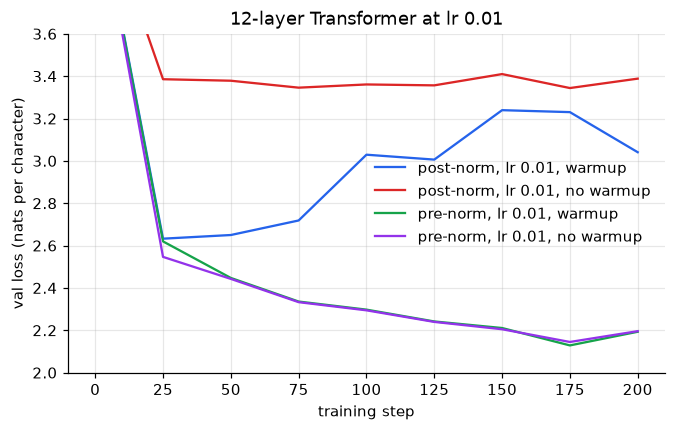

In [9]:
def train_deep(place, lr, warmup, norm=LayerNorm):
    torch.manual_seed(0)
    model = NormLM(tok.vocab_size, dim=64, n_layers=12, n_heads=4, norm=norm, place=place)
    start = time.time()
    hist = mlexp.train_lm(model, train_ids, val_ids, steps=200, lr=lr, batch_size=16, block_size=32,
                          eval_every=25, eval_iters=5, warmup_frac=warmup, log=False)
    hist["seconds"] = time.time() - start
    return hist


deep = {}
for lr, place, warmup in [(3e-3, "post", 0.0), (3e-3, "pre", 0.0),
                          (1e-2, "post", 0.1), (1e-2, "post", 0.0), (1e-2, "pre", 0.1), (1e-2, "pre", 0.0)]:
    name = f"{place}-norm, lr {lr:g}, " + ("warmup" if warmup else "no warmup")
    deep[name] = train_deep(place, lr, warmup)
    print(f"{name:34s} final val loss {deep[name]['val'][-1]:.3f}   ({deep[name]['seconds']:.0f}s)")

ax = mlexp.plot_histories({k: v for k, v in deep.items() if "0.01" in k}, "12-layer Transformer at lr 0.01")
ax.set_ylim(2.0, 3.6);

#### Why it worked: a post-mortem

**Pre-norm tolerates a higher learning rate.** At lr 0.003 the placement made little difference; at lr 0.01 post-norm failed and pre-norm trained to the best loss of any run. Higher stable learning rates are the practical reason pre-norm took over. **[established]**, matching Xiong et al. (2020) and Wang et al. (2019).

**Warmup only partly rescues post-norm.** With warmup, post-norm reached 2.63 by step 25, held there until step 50, and then lost what it had learned while the learning rate stayed high. Warmup delays the large early updates but does not remove their cause. Our loop also clips gradients, which softens the problem; we did not test how much worse post-norm is without clipping. **[likely]**

**The mechanism: an un-normalized identity path.** In pre-norm, the gradient reaching block `\(l\)` includes a direct term from the loss that skips every norm, so its size does not depend on depth. In post-norm it is rescaled by each LayerNorm on the way, and Xiong et al. show the last layers get large gradients at initialization. Liu et al. (2020) add a second view: in post-norm the output depends strongly on each residual branch, so a small change in the weights is amplified into a large change in the output. **[likely]**

**What pre-norm gives up.** Because the residual stream keeps growing as branches add to it, later blocks contribute a shrinking fraction of the stream, so a deep pre-norm model may use its depth less effectively. When post-norm trains (with careful warmup or rescaled residuals, as in DeepNet), it is sometimes slightly better. That trade-off is why variants such as "sandwich" norms, which normalize both the input and the output of each branch (used in Gemma 2 and 3), keep appearing. **[speculative]** as to which is best at scale.

### Step 4 (minor): RMSNorm

Zhang and Sennrich (2019) asked whether LayerNorm needs both of its operations. Re-centring (subtracting the mean) and re-scaling (dividing by the spread) can be separated, and their hypothesis was that the re-scaling does the useful work. **RMSNorm** divides each token by its root mean square and keeps only the learned gain: no mean, no bias. T5 used this simplified norm, LLaMA made it standard, and it is the norm in our `mlexp` Transformer.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: RMSNorm</p><div class="mlx-eq">$$\mathrm{RMSNorm}(x) = \gamma \odot \frac{x}{\sqrt{\tfrac{1}{d}\sum_{j=1}^{d} x_j^2 + \epsilon}}$$</div><p class="mlx-eq__where">If the features of \(x\) happen to have mean zero, this equals LayerNorm without the bias. It saves one reduction over the features and one subtraction.</p></div>

We repeat the best run from step 3 (pre-norm, lr 0.01, no warmup) with RMSNorm, and then time the norm layers on their own.

In [10]:
deep["pre-norm RMSNorm, lr 0.01, no warmup"] = h = train_deep("pre", 1e-2, 0.0, norm=RMSNorm)
ln = deep["pre-norm, lr 0.01, no warmup"]
print(f"LayerNorm: final val loss {ln['val'][-1]:.3f}  ({ln['seconds']:.0f}s)")
print(f"RMSNorm:   final val loss {h['val'][-1]:.3f}  ({h['seconds']:.0f}s)")


def time_norm(norm, x, reps=30):
    """Milliseconds for one forward and backward pass of a norm layer."""
    for _ in range(3):
        norm(x).sum().backward()
    start = time.perf_counter()
    for _ in range(reps):
        norm(x).sum().backward()
    return 1000 * (time.perf_counter() - start) / reps


x = torch.randn(32, 128, 512, requires_grad=True)
for name, norm in [("LayerNorm, hand-written", LayerNorm(512)), ("RMSNorm, hand-written", RMSNorm(512)),
                   ("nn.LayerNorm (PyTorch)", nn.LayerNorm(512)), ("nn.RMSNorm (PyTorch)", nn.RMSNorm(512))]:
    print(f"{name:28s} {time_norm(norm, x):6.1f} ms per forward + backward")

LayerNorm: final val loss 2.196  (24s)
RMSNorm:   final val loss 2.202  (22s)


LayerNorm, hand-written        62.6 ms per forward + backward


RMSNorm, hand-written          43.5 ms per forward + backward


nn.LayerNorm (PyTorch)          7.0 ms per forward + backward


nn.RMSNorm (PyTorch)           43.2 ms per forward + backward


The loss is essentially the same (2.202 against 2.196), which matches many published comparisons. **[established]**

The speed result is more interesting than the textbook story. Written by hand, RMSNorm is faster than LayerNorm (43.5 against 62.6 ms), because it skips the mean and the subtraction. But PyTorch's own `nn.LayerNorm` runs as a single fused kernel and is six to nine times faster than either, while `nn.RMSNorm` in our PyTorch version on CPU is no faster than the hand-written one (43.2 ms). On this machine, the kernel matters far more than the formula. Zhang and Sennrich reported 7% to 64% faster training on their RNN models; inside a Transformer the norms are a small fraction of the compute, so the end-to-end gain is a few percent at most (our two training runs took 24 and 22 seconds, within timing noise). **[likely]** RMSNorm won mostly because it is simpler and loses nothing, and because GPU frameworks now ship fused kernels for it, not because the formula is much cheaper.

Why does dropping the mean not hurt? One argument is that the following linear layer can absorb any constant shift, so centring the input buys little. Another is that what matters for stability is bounding the size of the vector, which the RMS already does. **[speculative]**: neither has been tested carefully.

### Step 5 (major): QK-norm

#### The problem before

Pre-norm and RMSNorm keep the residual stream under control, but one quantity inside each block is still unbounded: the attention logit `\(q \cdot k / \sqrt{d}\)`. Both `\(q\)` and `\(k\)` are linear in the weights, so the logit grows roughly with the *square* of the weights. When Dehghani et al. (2023) scaled a Vision Transformer to 22 billion parameters, training diverged after a few thousand steps, and they traced it to attention logits growing to tens of thousands. The softmax then puts all its weight on one token (the attention entropy collapses, Zhai et al., 2023), its gradient becomes nearly zero almost everywhere and huge in a few places, and training breaks.

#### The idea

Normalize the queries and keys of each head, just before the dot product. With RMSNorm, every `\(q\)` and `\(k\)` has length exactly `\(\sqrt{d}\)` (times a learned gain), so every logit is bounded. Henry et al. (2020) first proposed this for translation; ViT-22B made it a stability fix at scale, and Wortsman et al. (2023) showed the same failure appears in small models trained at high learning rates, which is what lets us reproduce it on a CPU. OLMo 2, Gemma 3 and Qwen3 all use QK-norm.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: QK-norm bounds the logits</p><div class="mlx-eq">$$\ell_{ij} = \frac{\hat{q}_i \cdot \hat{k}_j}{\sqrt{d}}, \quad \hat{q} = g_q \odot \frac{q}{\mathrm{rms}(q)}, \;\; \hat{k} = g_k \odot \frac{k}{\mathrm{rms}(k)} \qquad\Longrightarrow\qquad |\ell_{ij}| \le \sqrt{d}\, \max|g_q|\, \max|g_k|$$</div><p class="mlx-eq__where">\(d\) is the head dimension (16 here). Without the norm, \(|\ell_{ij}|\) is bounded only by the size of the weight matrices, which training can grow without limit.</p></div>

#### Experiment: attention logits at high learning rates

We train a 4-layer pre-norm RMSNorm model for 300 steps at three learning rates, with and without QK-norm, and record the largest attention logit in the whole model at every step. Six runs, about 20 seconds each.

lr 0.01  no QK-norm  largest logit    45.9   final val loss 2.066


lr 0.01  QK-norm     largest logit    11.0   final val loss 2.056


lr 0.03  no QK-norm  largest logit   166.6   final val loss 2.138


lr 0.03  QK-norm     largest logit    14.2   final val loss 2.090


lr 0.1   no QK-norm  largest logit  1531.5   final val loss 2.452


lr 0.1   QK-norm     largest logit    21.0   final val loss 2.207


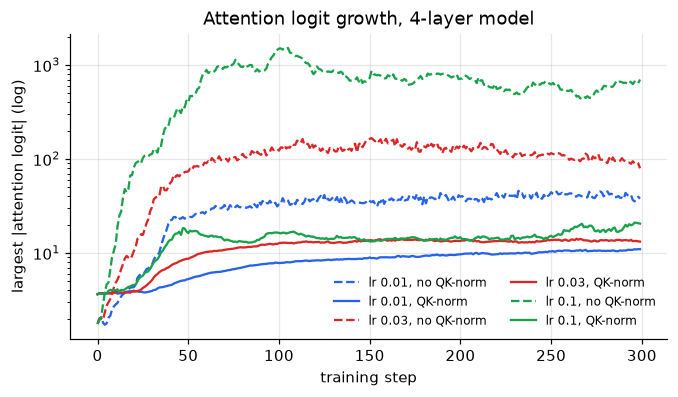

In [11]:
@torch.no_grad()
def val_loss(model, iters=10):
    gen = torch.Generator().manual_seed(1234)
    model.eval()
    losses = [model(*mlexp.get_batch(val_ids, 16, 64, gen))[1].item() for _ in range(iters)]
    model.train()
    return sum(losses) / iters


def train_tracking(qk_norm, lr, steps=300):
    """AdamW with a short warmup; records the largest attention logit at every step."""
    torch.manual_seed(0)
    model = NormLM(tok.vocab_size, dim=64, n_layers=4, n_heads=4, norm=RMSNorm, place="pre", qk_norm=qk_norm)
    gen = torch.Generator().manual_seed(0)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    max_logit = []
    for step in range(steps):
        for group in opt.param_groups:
            group["lr"] = lr * min(1.0, (step + 1) / 30)
        x, y = mlexp.get_batch(train_ids, 16, 64, gen)
        _, loss = model(x, y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        max_logit.append(max(block.attn.max_logit for block in model.blocks))
    return max_logit, val_loss(model)


qk_runs = {}
for lr in [1e-2, 3e-2, 1e-1]:
    for qk in [False, True]:
        qk_runs[(lr, qk)] = train_tracking(qk, lr)
        logits, loss = qk_runs[(lr, qk)]
        print(f"lr {lr:<5g} {'QK-norm   ' if qk else 'no QK-norm'}  largest logit {max(logits):7.1f}   final val loss {loss:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, lr in enumerate([1e-2, 3e-2, 1e-1]):
    for qk in [False, True]:
        ax.semilogy(qk_runs[(lr, qk)][0], color=mlexp.plot.PALETTE[i], ls="-" if qk else "--",
                    label=f"lr {lr:g}, " + ("QK-norm" if qk else "no QK-norm"))
ax.set(xlabel="training step", ylabel="largest |attention logit| (log)", title="Attention logit growth, 4-layer model")
ax.legend(frameon=False, fontsize=8, ncol=2);

#### Why it worked: a post-mortem

**Without QK-norm, the logits grow with the learning rate.** The largest logit rose from 46 at lr 0.01 to 167 at lr 0.03 and 1532 at lr 0.1. A logit difference of 20 already gives one token about `\(e^{20} \approx 5 \times 10^8\)` times the weight of another, so at these values many heads attend to a single token. This is the attention-logit-growth instability of Dehghani et al. (2023) and Wortsman et al. (2023), reproduced at toy scale. **[established]**

**With QK-norm, the logits stay small at every learning rate** (11 to 21), and the validation loss is better at every learning rate we tried, by the largest margin at lr 0.1 (2.21 against 2.45). Our small model never fully diverged, because gradient clipping and the short run protect it, but the trend is the one that makes large runs fail. **[established]** for the bound; **[likely]** for how much loss it saves in general.

**Why bounding the logit is enough.** The logit is the one place in the block where two learned projections multiply, so it is the quantity that grows fastest when the weights grow. Everything else in a pre-norm block passes through a norm before it is used. QK-norm closes that last gap. The bound also has a cost: with a small head dimension and small gains, a head cannot become very sharp, which is why the gains are learned. **[likely]**

**What remains.** The output logits of the language-model head can also grow and cause a similar divergence; the usual fix there is an auxiliary "z-loss" that keeps the softmax normalizer near 1 (PaLM, 2022; Wortsman et al., 2023). **[established]** Whether QK-norm should become universal or stay a fix for very large or very high-learning-rate runs is not settled. **[speculative]**

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| no normalization, accuracy at lr 0.1 | 0.824 | 0.830 ± 0.019 | 0.824 / 0.851 / 0.815 |
| BatchNorm, accuracy at lr 0.3 | 0.827 | 0.822 ± 0.013 | 0.827 / 0.832 / 0.807 |
| post-norm, lr 0.003 | 2.224 | 2.206 ± 0.017 | 2.224 / 2.191 / 2.203 |
| pre-norm, lr 0.003 | 2.243 | 2.221 ± 0.025 | 2.243 / 2.194 / 2.225 |
| post-norm, lr 0.01, warmup | 3.041 | 2.965 ± 0.381 | 3.041 / 3.303 / 2.552 |
| post-norm, lr 0.01, no warmup | 3.388 | 3.354 ± 0.034 | 3.388 / 3.353 / 3.320 |
| pre-norm, lr 0.01, warmup | 2.193 | 2.166 ± 0.027 | 2.193 / 2.140 / 2.164 |
| pre-norm, lr 0.01, no warmup | 2.196 | 2.173 ± 0.021 | 2.196 / 2.154 / 2.169 |
| LayerNorm | 2.196 | 2.173 ± 0.021 | 2.196 / 2.154 / 2.169 |
| RMSNorm | 2.202 | 2.180 ± 0.023 | 2.202 / 2.156 / 2.181 |
| lr 0.01, no QK-norm | 2.066 | 2.052 ± 0.019 | 2.066 / 2.060 / 2.030 |
| lr 0.01, QK-norm | 2.056 | 2.037 ± 0.017 | 2.056 / 2.032 / 2.023 |
| lr 0.03, no QK-norm | 2.138 | 2.129 ± 0.023 | 2.138 / 2.147 / 2.103 |
| lr 0.03, QK-norm | 2.090 | 2.077 ± 0.015 | 2.090 / 2.081 / 2.061 |
| lr 0.1, no QK-norm | 2.452 | 2.406 ± 0.060 | 2.452 / 2.428 / 2.339 |
| lr 0.1, QK-norm | 2.207 | 2.199 ± 0.025 | 2.207 / 2.220 / 2.171 |

Every comparison came out the same way in all three seeds: post-norm slightly ahead at lr 0.003, failing at lr 0.01 with or without warmup, LayerNorm and RMSNorm tied, and QK-norm better at every learning rate.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Write BatchNorm, LayerNorm and RMSNorm, and say which axis each one normalizes over.</li><li>Explain why internal covariate shift is not the main reason BatchNorm works, and what the smoothness view says instead.</li><li>Explain why pre-norm trains deep Transformers at learning rates where post-norm fails.</li><li>Explain how QK-norm bounds the attention logits, and measure logit growth yourself.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>Why can a language model not simply use BatchNorm during generation?</summary><p>Generation often runs on a single sequence, one token at a time, so there may be no batch to take statistics over. Running averages from training would have to stand in, and they differ from the statistics the model was trained with. LayerNorm and RMSNorm use only the token itself.</p></details><details><summary>Injecting random shifts after BatchNorm did not stop it from training at a high learning rate. What does this say about the covariate-shift explanation?</summary><p>If keeping each layer's input distribution fixed were the main benefit, adding shift should have removed it. The network lost some accuracy but still trained at a learning rate where the plain network diverged, so the benefit must come from somewhere else, such as a smoother loss surface or the scale invariance of the normalized layer.</p></details><details><summary>QK-norm with RMSNorm, head dimension 16, and gains of 1: what is the largest possible attention logit?</summary><p>Each normalized q and k has length 4 (the square root of 16), so their dot product is at most 16, and dividing by 4 gives 4. The learned gains can raise this bound, which is why our runs reached about 20.</p></details></div>

## Further reading

- Ioffe and Szegedy, 2015, [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/abs/1502.03167).
- Ba, Kiros and Hinton, 2016, [Layer Normalization](https://arxiv.org/abs/1607.06450).
- Santurkar, Tsipras, Ilyas and Madry, 2018, [How Does Batch Normalization Help Optimization?](https://arxiv.org/abs/1805.11604): the covariate-shift test and the smoothness view.
- Bjorck, Gomes, Selman and Weinberger, 2018, [Understanding Batch Normalization](https://arxiv.org/abs/1806.02375): the benefit comes mostly from larger learning rates.
- Xiong et al., 2020, [On Layer Normalization in the Transformer Architecture](https://arxiv.org/abs/2002.04745): why pre-norm trains without warmup.
- Zhang and Sennrich, 2019, [Root Mean Square Layer Normalization](https://arxiv.org/abs/1910.07467).
- Dehghani et al., 2023, [Scaling Vision Transformers to 22 Billion Parameters](https://arxiv.org/abs/2302.05442): QK-norm against attention logit growth.
- Wortsman et al., 2023, [Small-scale proxies for large-scale Transformer training instabilities](https://arxiv.org/abs/2309.14322).
- Liu et al., 2022, [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545).
- Brock et al., 2021, [High-Performance Large-Scale Image Recognition Without Normalization](https://arxiv.org/abs/2102.06171): NFNets.
- Zhu et al., 2025, [Transformers without Normalization](https://arxiv.org/abs/2503.10622): Dynamic Tanh.
- Gemma Team, 2024, [Gemma 2: Improving Open Language Models at a Practical Size](https://arxiv.org/abs/2408.00118).
- Team OLMo et al., 2024, [2 OLMo 2 Furious](https://arxiv.org/abs/2501.00656).